In [4]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 3.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.0 MB 3.4 MB/s eta 0:00:03
   --------- ------------------------------ 1.8/8.0 MB 3.1 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.0 MB 3.1 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.0 MB 3.1 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.0 MB 3.2 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.0 MB 3.3 MB/s eta 0:00:02
   -------------------------- ------------- 5.2/8.0 MB 3.3 MB/s eta 0:00:01
   ------------------------------ --------- 6.0/8.0 MB 3.3 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.0 MB 3.3 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.0 MB 3.3 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 3.3 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
%pip install xgboost
%pip install shap

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 9.6 MB/s eta 0:00:11
   - -------------------------------------- 3.9/101.7 MB 10.7 MB/s eta 0:00:10
   -- ------------------------------------- 7.3/101.7 MB 12.6 MB/s eta 0:00:08
   --- ------------------------------------ 10.0/101.7 MB 12.7 MB/s eta 0:00:08
   ----- ---------------------------------- 13.4/101.7 MB 13.3 MB/s eta 0:00:07
   ------ --------------------------------- 17.3/101.7 MB 14.2 MB/s eta 0:00:06
   -------- ------------------------------- 21.2/101.7 MB 14.8 MB/s eta 0:00:06
   --------- ------------------------------ 24.6/101.7 MB 14.9 MB/s eta 0:00:06
   ---------- ----------------------------- 27.3/101.7 MB 14.8 MB/s eta 0:00:06
   ----------- ---------------------------- 29.9/101.7 MB 14.6 MB/s eta 0:00:05
   ------------ --------------------------- 31.5/101.7 MB 14.1 MB/s eta 0:00:05
   ------------- -------------------------- 33.8/101.


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 6.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -- ------------------------------------- 2.4/38.1 MB 10.3 MB/s eta 0:00:04
   ----- ---------------------------------- 5.0/38.1 MB 11.6 MB/s eta 0:00:03
   -------- ------------------------------- 7.9/38.1 MB 12.5 MB/s eta 0:00:03
   ----------- ---------------------------- 10.7/38.1 MB 12.7 MB/s eta 0:00:03
   ------------- -------------------------- 12.8/38.1 MB 12.2 MB/s eta 0:00:03
   --------------- ------------------------ 15.2/38.1 MB 12.1 MB/s eta 0:00:02
   ------------------ --------------------- 17.8/38.1 MB 12.0 MB/s eta 0:00:02
   -------------------- ------------------- 19.9/38.1 MB 11.8 MB/s eta 0:00:02
   ----------------------- ---------------- 22.0/38.1 MB 11.7 MB/s eta 0:00:02
   ------------------------ --------------- 23.3/38.1 MB 11.2 MB/s eta 


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
SEED = 42
print("✓ Librerías cargadas")

c:\Users\USUARIO\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Librerías cargadas


In [8]:
# Carga y preparación
df = pd.read_csv('../data/processed/df_master_final.csv')

FEATURES = ['total_delitos', 'extorsion', 'homicidio', 'hurto_a_persona',
            'hurto_a_residencia', 'hurto_de_carro', 'hurto_de_moto',
            'hurto_de_semoviente', 'victimas_viales', 'muertos_viales']

le = LabelEncoder()
le.fit(['bajo', 'medio', 'alto'])
df['target'] = le.transform(df['nivel_bienestar'])

X = df[FEATURES]
y = df['target']

print(f"Dataset: {df.shape[0]} filas, {len(FEATURES)} features")
print(f"Clases: bajo=0, medio=1, alto=2")
print(f"Distribución: {dict(zip(*np.unique(y, return_counts=True)))}")

Dataset: 112 filas, 10 features
Clases: bajo=0, medio=1, alto=2
Distribución: {np.int64(0): np.int64(37), np.int64(1): np.int64(38), np.int64(2): np.int64(37)}


In [9]:
# División del dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train:      {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validación: {X_val.shape[0]}  filas ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test:       {X_test.shape[0]}  filas ({X_test.shape[0]/len(X)*100:.0f}%)")

Train:      78 filas (70%)
Validación: 17  filas (15%)
Test:       17  filas (15%)


In [10]:
# Función de evaluación
def evaluar(nombre, modelo, X_tr, y_tr, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='macro')

    if hasattr(modelo, 'predict_proba'):
        y_prob = modelo.predict_proba(X_te)
        auc = roc_auc_score(y_te, y_prob, multi_class='ovr', average='macro')
    else:
        auc = float('nan')

    print(f"\n{'='*45}")
    print(f"{nombre}")
    print(f"  Accuracy : {acc:.3f}")
    print(f"  F1-macro : {f1:.3f}")
    print(f"  AUC-ROC  : {auc:.3f}")
    print(f"\n{classification_report(y_te, y_pred, target_names=['bajo','medio','alto'])}")

    return {'modelo': nombre, 'accuracy': acc, 'f1_macro': f1, 'auc_roc': auc,
            'clf': modelo, 'y_pred': y_pred}

resultados = []
print("✓ Función de evaluación lista")

✓ Función de evaluación lista


In [11]:
# Baseline
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
res = evaluar('Baseline', dummy, X_train, y_train, X_test, y_test)
resultados.append(res)


Baseline
  Accuracy : 0.353
  F1-macro : 0.174
  AUC-ROC  : 0.500

              precision    recall  f1-score   support

        bajo       0.35      1.00      0.52         6
       medio       0.00      0.00      0.00         6
        alto       0.00      0.00      0.00         5

    accuracy                           0.35        17
   macro avg       0.12      0.33      0.17        17
weighted avg       0.12      0.35      0.18        17



In [12]:
# Árbol de decisión
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=3, random_state=SEED)
res = evaluar('Árbol de decisión', dt, X_train, y_train, X_test, y_test)
resultados.append(res)

cv = cross_val_score(dt, X_train, y_train, cv=StratifiedKFold(5), scoring='f1_macro')
print(f"CV F1-macro (5-fold): {cv.mean():.3f} ± {cv.std():.3f}")


Árbol de decisión
  Accuracy : 0.824
  F1-macro : 0.817
  AUC-ROC  : 0.968

              precision    recall  f1-score   support

        bajo       0.86      1.00      0.92         6
       medio       1.00      0.67      0.80         6
        alto       0.67      0.80      0.73         5

    accuracy                           0.82        17
   macro avg       0.84      0.82      0.82        17
weighted avg       0.85      0.82      0.82        17

CV F1-macro (5-fold): 0.773 ± 0.086


In [13]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=2,
                             random_state=SEED, n_jobs=-1)
res = evaluar('Random Forest', rf, X_train, y_train, X_test, y_test)
resultados.append(res)

cv = cross_val_score(rf, X_train, y_train, cv=StratifiedKFold(5), scoring='f1_macro')
print(f"CV F1-macro (5-fold): {cv.mean():.3f} ± {cv.std():.3f}")


Random Forest
  Accuracy : 0.941
  F1-macro : 0.939
  AUC-ROC  : 0.989

              precision    recall  f1-score   support

        bajo       1.00      1.00      1.00         6
       medio       1.00      0.83      0.91         6
        alto       0.83      1.00      0.91         5

    accuracy                           0.94        17
   macro avg       0.94      0.94      0.94        17
weighted avg       0.95      0.94      0.94        17

CV F1-macro (5-fold): 0.811 ± 0.136


In [14]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=SEED,
    verbosity=0
)
res_xgb = evaluar('XGBoost', xgb, X_train, y_train, X_test, y_test)
resultados.append(res_xgb)

cv = cross_val_score(xgb, X_train, y_train, cv=StratifiedKFold(5), scoring='f1_macro')
print(f"CV F1-macro (5-fold): {cv.mean():.3f} ± {cv.std():.3f}")


XGBoost
  Accuracy : 0.941
  F1-macro : 0.937
  AUC-ROC  : 0.973

              precision    recall  f1-score   support

        bajo       1.00      1.00      1.00         6
       medio       0.86      1.00      0.92         6
        alto       1.00      0.80      0.89         5

    accuracy                           0.94        17
   macro avg       0.95      0.93      0.94        17
weighted avg       0.95      0.94      0.94        17

CV F1-macro (5-fold): 0.822 ± 0.122


           modelo  accuracy  f1_macro  auc_roc
         Baseline     0.353     0.174    0.500
Árbol de decisión     0.824     0.817    0.968
    Random Forest     0.941     0.939    0.989
          XGBoost     0.941     0.937    0.973


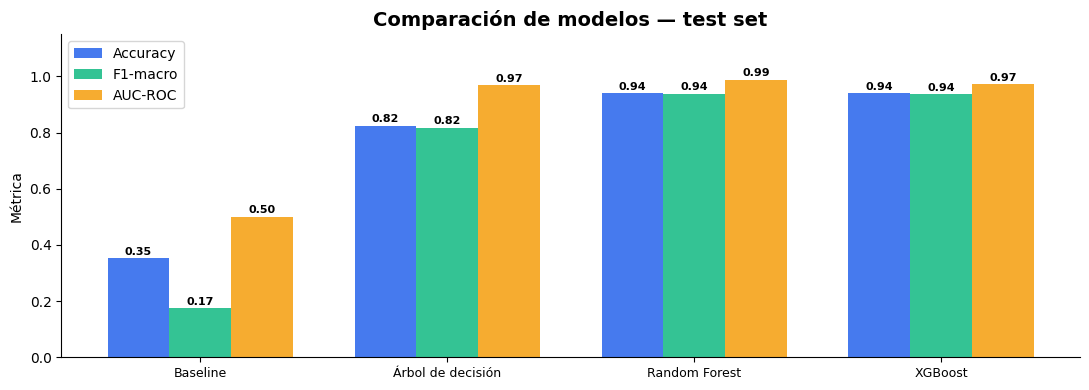

In [15]:
# Comparación de modelos
tabla = pd.DataFrame([{k: v for k, v in r.items() if k not in ['clf','y_pred']}
                       for r in resultados])
tabla[['accuracy','f1_macro','auc_roc']] = tabla[['accuracy','f1_macro','auc_roc']].round(3)
print(tabla.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(tabla))
w = 0.25
b1 = ax.bar(x - w, tabla['accuracy'], w, label='Accuracy',  color='#2563eb', alpha=0.85)
b2 = ax.bar(x,     tabla['f1_macro'], w, label='F1-macro',  color='#10b981', alpha=0.85)
b3 = ax.bar(x + w, tabla['auc_roc'],  w, label='AUC-ROC',   color='#f59e0b', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(tabla['modelo'], fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Métrica')
ax.set_title('Comparación de modelos — test set', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/viz9_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

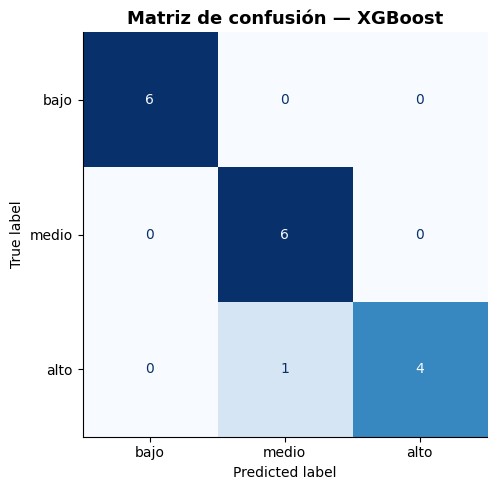

In [16]:
# Matriz de confusión XGBoost
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, res_xgb['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['bajo', 'medio', 'alto'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/viz10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

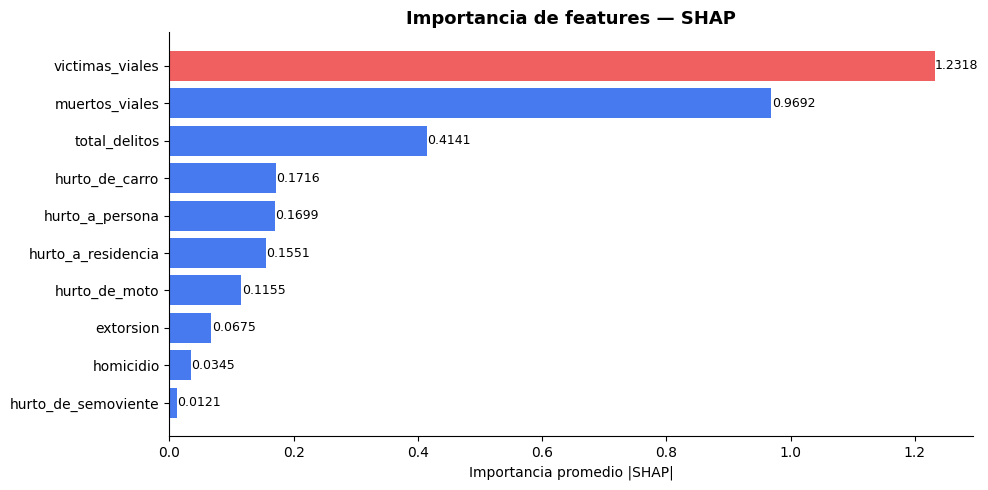


Ranking:
  1. victimas_viales: 1.2318
  2. muertos_viales: 0.9692
  3. total_delitos: 0.4141
  4. hurto_de_carro: 0.1716
  5. hurto_a_persona: 0.1699
  6. hurto_a_residencia: 0.1551
  7. hurto_de_moto: 0.1155
  8. extorsion: 0.0675
  9. homicidio: 0.0345
  10. hurto_de_semoviente: 0.0121


In [36]:
# importancia de features
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

xgb_final = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=SEED, verbosity=0
)
xgb_final.fit(X_trainval, y_trainval)

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)

# Promedios muestras y clases
shap_mean = np.abs(shap_values).mean(axis=0).mean(axis=1)
feat_importance = pd.Series(shap_mean, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#ef4444' if v == feat_importance.max() else '#2563eb' for v in feat_importance.values]
bars = ax.barh(feat_importance.index, feat_importance.values, color=colores, alpha=0.85)
for bar, val in zip(bars, feat_importance.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Importancia de features — SHAP', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia promedio |SHAP|')
plt.tight_layout()
plt.savefig('../reports/figures/viz11_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRanking:")
for i, (feat, val) in enumerate(feat_importance.sort_values(ascending=False).items()):
    print(f"  {i+1}. {feat}: {val:.4f}")